# updated version of RD900 analysis to detect region differences using raw reads

links

* https://journals.plos.org/plospathogens/article?id=10.1371/journal.ppat.1009061
* https://dmnfarrell.github.io/bioinformatics/rd900-mtbc

In [209]:
import os, io, csv, glob, subprocess, time, re
import posixpath, urllib, gzip, shutil
from importlib import reload
from pathlib import Path
from collections import defaultdict
import pandas as pd
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.SeqFeature import SeqFeature, FeatureLocation
from Bio import Entrez
from BCBio import GFF
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import pylab as plt
import seaborn as sns
import networkx as nx
from snipgenie import tools, aligners, app, trees, plotting
pd.set_option('display.max_rows', 300)
pd.set_option('display.max_colwidth', 100)

In [18]:
Entrez.email = "you@example.com"
Entrez.api_key = "8bffceb973ebf5e6d371cc55a8244ae66a09"

In [7]:
species = [ 
        #'Mycobacterium tuberculosis',
        'Mycobacterium tuberculosis variant bovis',
        'Mycobacterium tuberculosis variant africanum' ,
        'Mycobacterium tuberculosis variant caprae',
        'Mycobacterium orygis',
        'Mycobacterium tuberculosis variant microti',
        'Mycobacterium tuberculosis variant pinnipedii', 
        'Mycobacterium tuberculosis variant suricattae'
    ]  

## complete genomes for MTB species

In [187]:
def build_query(species: List[str]) -> str:
    """Build an Entrez query: (species OR species OR ...) AND Complete Genome."""
    
    species_clause = " OR ".join(f'"{sp}"[Organism]' for sp in species)
    query = f'({species_clause})'
    return query

def esearch_all_ids(query: str, db: str = "assembly", batch_size: int = 500) -> List[str]:
    """Run esearch with history, return all UIDs (handles >retmax results)."""
    handle = Entrez.esearch(db=db, term=query, usehistory="y", retmax=0)
    result = Entrez.read(handle)
    handle.close()
 
    count = int(result["Count"])
    webenv = result["WebEnv"]
    query_key = result["QueryKey"]
 
    print(f"Query: {query}")
    print(f"Total matching assemblies: {count}")
 
    ids: List[str] = []
    for start in range(0, count, batch_size):
        handle = Entrez.esearch(
            db=db,
            term=query,
            retstart=start,
            retmax=batch_size,
            usehistory="y",
            webenv=webenv,
            query_key=query_key,
        )
        batch = Entrez.read(handle)
        handle.close()
        ids.extend(batch["IdList"])
        time.sleep(0.34)  # be polite; adjust down if you have an API key
 
    return ids
 
def esummary_records(ids: List[str], db: str = "assembly", batch_size: int = 200) -> List[Dict]:
    """Fetch docsummaries for a list of assembly UIDs, in batches."""
    records = []
    for i in range(0, len(ids), batch_size):
        chunk = ids[i : i + batch_size]
        handle = Entrez.esummary(db=db, id=",".join(chunk), report="full")
        result = Entrez.read(handle, validate=False)
        handle.close()
 
        for doc in result["DocumentSummarySet"]["DocumentSummary"]:
            records.append(
                {
                    "AssemblyAccession": doc.get("AssemblyAccession", ""),
                    "GbUid": doc.get("GbUid", ""),
                    "AssemblyName": doc.get("AssemblyName", ""),
                    "Organism": doc.get("Organism", ""),
                    "SpeciesName": doc.get("SpeciesName", ""),
                    "Infraspecies": doc.get("Biosource", {}).get("InfraspeciesList", ""),
                    "AssemblyStatus": doc.get("AssemblyStatus", ""),  # should be "Complete Genome"
                    "AssemblyType": doc.get("AssemblyType", ""),
                    "SubmitterOrganization": doc.get("SubmitterOrganization", ""),
                    "SubmissionDate": doc.get("SubmissionDate", ""),
                    "LastUpdateDate": doc.get("LastUpdateDate", ""),
                    "BioSampleAccn": doc.get("BioSampleAccn", ""),
                    "FtpPath_GenBank": doc.get("FtpPath_GenBank", ""),
                    "FtpPath_RefSeq": doc.get("FtpPath_RefSeq", ""),
                }
            )
        time.sleep(0.34)
 
    return records

def records_to_dataframe(records: List[Dict]) -> pd.DataFrame:
    """Convert the list of assembly-summary dicts into a pandas DataFrame."""
    df = pd.DataFrame(records)
    if not df.empty:
        for date_col in ("SubmissionDate", "LastUpdateDate"):
            if date_col in df.columns:
                df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    return df

In [89]:
def _biosample_accessions_to_uids(
    accessions: List[str], chunk_size: int = 50
) -> Dict[str, str]:
    """
    Resolve BioSample accessions (e.g. "SAMN12345678") to their internal
    Entrez BioSample UIDs, batching many accessions per esearch call
    (OR-joined) rather than one call per accession.
 
    Returns {accession: uid}. An accession with no hit is simply absent
    from the result (caller should treat missing as "no BioSample data").
    """
    acc_to_uid: Dict[str, str] = {}
    uid_to_check: List[str] = []
 
    for i in range(0, len(accessions), chunk_size):
        chunk = accessions[i : i + chunk_size]
        term = " OR ".join(f'"{acc}"[Accession]' for acc in chunk)
        handle = Entrez.esearch(db="biosample", term=term, retmax=len(chunk) * 2)
        result = Entrez.read(handle)
        handle.close()
        uid_to_check.extend(result["IdList"])
        time.sleep(0.34)
 
    # We now have UIDs but not yet the accession->uid mapping (esearch doesn't
    # preserve term-to-hit correspondence for an OR query); resolve that via
    # esummary, which returns each UID's actual accession.
    for i in range(0, len(uid_to_check), 200):
        batch = uid_to_check[i : i + 200]
        handle = Entrez.esummary(db="biosample", id=",".join(batch))
        result = Entrez.read(handle, validate=False)
        handle.close()
        for doc in result["DocumentSummarySet"]["DocumentSummary"]:
            acc = doc.get("Accession", "")
            if acc in accessions:
                acc_to_uid[acc] = doc.attributes["uid"]
        time.sleep(0.34)
 
    return acc_to_uid
 
def _parse_biosample_xml(sample_data_xml: str) -> dict:
    """Parse one BioSample record's embedded SampleData XML into a flat dict."""
    parsed = {}
    try:
        root = ET.fromstring(sample_data_xml)
    except ET.ParseError:
        return parsed
 
    for attr in root.findall(".//Attribute"):
        name = attr.get("harmonized_name") or attr.get("attribute_name")
        if name:
            parsed[name] = (attr.text or "").strip()
 
    org_elem = root.find(".//Organism")
    if org_elem is not None:
        parsed["biosample_organism"] = org_elem.text
        if org_elem.get("taxonomy_id"):
            parsed["biosample_taxonomy_id"] = org_elem.get("taxonomy_id")
 
    title_elem = root.find(".//Title")
    if title_elem is not None and title_elem.text:
        parsed["biosample_title"] = title_elem.text.strip()
 
    return parsed

def fetch_biosample_attributes(
    df: pd.DataFrame,
    biosample_col: str = "BioSampleAccn",
    prefix: str = "bs_",
    batch_size: int = 200,
) -> pd.DataFrame:
    """
    Pull full BioSample attribute sets (geo_loc_name, host, collection_date,
    strain, isolation_source, lat_lon, etc.) for every BioSample accession in
    `df[biosample_col]`, and merge them back in as new columns.
 
    Attribute sets vary a lot between submissions, so this does NOT assume a
    fixed schema -- whatever attributes exist for a given sample become
    columns; samples missing an attribute just get NaN there. New columns
    are prefixed (default "bs_") to avoid colliding with your existing ones.
 
    Requires Entrez.email (and ideally Entrez.api_key) already set, exactly
    as in the rest of this script.
 
    Timing: this does ~1 esearch call per `chunk_size` accessions plus
    ~1 esummary call per `batch_size` UIDs -- for ~600 samples with an API
    key (10 req/s) expect roughly 1-2 minutes.
    """
    accessions = sorted(set(df[biosample_col].dropna().astype(str)) - {""})
    if not accessions:
        print("No BioSample accessions found in the given column; returning df unchanged.")
        return df
 
    print(f"Resolving {len(accessions)} BioSample accessions to UIDs...")
    acc_to_uid = _biosample_accessions_to_uids(accessions)
    print(f"Resolved {len(acc_to_uid)} / {len(accessions)} accessions.")
 
    uids = list(acc_to_uid.values())
    uid_to_acc = {v: k for k, v in acc_to_uid.items()}
 
    records = []
    for i in range(0, len(uids), batch_size):
        batch = uids[i : i + batch_size]
        handle = Entrez.esummary(db="biosample", id=",".join(batch))
        result = Entrez.read(handle, validate=False)
        handle.close()
 
        for doc in result["DocumentSummarySet"]["DocumentSummary"]:
            uid = doc.attributes["uid"]
            acc = uid_to_acc.get(uid, doc.get("Accession", ""))
            attrs = _parse_biosample_xml(doc.get("SampleData", ""))
            attrs[biosample_col] = acc
            records.append(attrs)
 
        print(f"  fetched attributes for {min(i + batch_size, len(uids))}/{len(uids)} BioSamples")
        time.sleep(0.34)
 
    if not records:
        print("No BioSample attribute records retrieved; returning df unchanged.")
        return df
 
    attr_df = pd.DataFrame(records)
    attr_df = attr_df.rename(
        columns={c: f"{prefix}{c}" for c in attr_df.columns if c != biosample_col}
    )
 
    merged = df.merge(attr_df, on=biosample_col, how="left")
    n_new_cols = len(attr_df.columns) - 1
    print(f"Merged in {n_new_cols} BioSample attribute columns for {len(attr_df)} samples.")
    return merged
    

In [90]:
def post_process(df):
    def get_strain(x):
        if len(x)==0: return None
        return x[0]['Sub_value']
    df['strain']=df.Infraspecies.apply(get_strain)
    df.drop('Infraspecies',axis=1,inplace=True)
    return df

In [ ]:
query = build_query(species)
ids = esearch_all_ids(query)
records = esummary_records(ids)
other_asm = records_to_dataframe(records)

In [91]:
query = build_query(['Mycobacterium Tuberculosis'])
ids = esearch_all_ids(query)
records = esummary_records(ids)
mtb_asm = records_to_dataframe(records)
mtb_asm = post_process(mtb_asm)

Query: ("Mycobacterium Tuberculosis"[Organism]) AND "Complete Genome"[Assembly Level]
Total matching assemblies: 688


In [ ]:
mtb_asm=fetch_biosample_attributes(mtb_asm)
#mtb_asm.dropna(axis=1, how='all')

## lineage assignment for assemblies

In [93]:
lindf=pd.read_csv('lineage_table.tsv',sep='\t')
mtb_asm=mtb_asm.merge(lindf,left_on='AssemblyAccession',right_on='Isolate',how='left')
mtb_asm['species'] = mtb_asm['Organism'].str.extract(r'variant\s+(\w+)', expand=False).fillna('mtb')
mtb_asm.to_csv('asm_complete_mtbc.csv',index=False)

## incomplete long read assemblies

In [185]:
LONG_READ_PLATFORMS = {"OXFORD_NANOPORE", "PACBIO_SMRT"}
LONG_READ_INSTRUMENT_KEYWORDS = [
    "minion", "gridion", "promethion", "sequel", "rsii", "revio", "nanopore", "pacbio",
]

def _parse_sra_platform(exp_xml_str: str):
    """Parse an SRA esummary 'ExpXml' blob for (platform, instrument_model)."""
    try:
        root = ET.fromstring(f"<root>{exp_xml_str}</root>")
    except ET.ParseError:
        return None, None
    platform_elem = root.find(".//Platform")
    if platform_elem is None:
        return None, None
    platform = (platform_elem.text or "").strip()
    instrument = platform_elem.get("instrument_model", "")
    return platform, instrument
 
 
def is_long_read(platforms) -> bool:
    """
    platforms: list of (platform, instrument) tuples, as returned per-sample by
    get_sra_platforms_for_biosamples(). True if ANY linked SRA run used a
    long-read platform -- a hybrid (Illumina + ONT/PacBio) sample counts as
    long-read, since long-read data does exist for it.
    """
    for platform, instrument in platforms:
        if platform and platform.upper() in LONG_READ_PLATFORMS:
            return True
        if instrument and any(kw in instrument.lower() for kw in LONG_READ_INSTRUMENT_KEYWORDS):
            return True
    return False
 
def get_sra_platforms_for_biosamples(
    biosample_accessions: List[str], batch_size: int = 200
) -> Dict[str, list]:
    """
    For each BioSample accession, find linked SRA experiments (via elink) and
    return their sequencing platform(s) -- {accession: [(platform, instrument), ...]}.
    This is how you tell which assemblies came from long-read sequencing, since
    that information lives in SRA metadata, not in the assembly record itself.
 
    Reuses _biosample_accessions_to_uids() (same accession->UID resolution as
    fetch_biosample_attributes). elink is called one BioSample at a time --
    slower than the batched esearch/esummary calls elsewhere in this file, but
    multi-ID elink calls collapse links from all input IDs into one merged
    result rather than keeping them separable per sample, so batching here
    would silently cross-contaminate which SRA runs belong to which BioSample.
 
    Timing: roughly 1 elink + 1 esummary call per BioSample -- for a few
    hundred samples with an API key, expect a few minutes.
    """
    accessions = sorted(set(biosample_accessions) - {None, ""})
    if not accessions:
        return {}
 
    acc_to_uid = _biosample_accessions_to_uids(accessions)
    results = {acc: [] for acc in accessions}
 
    for acc, bs_uid in acc_to_uid.items():
        try:
            handle = Entrez.elink(dbfrom="biosample", db="sra", id=bs_uid)
            linkresult = Entrez.read(handle)
            handle.close()
        except Exception as e:
            print(f"  [warn] elink failed for {acc}: {e}")
            time.sleep(0.34)
            continue
 
        sra_uids = []
        for linkset in linkresult:
            for linksetdb in linkset.get("LinkSetDb", []):
                sra_uids.extend(l["Id"] for l in linksetdb["Link"])
 
        if not sra_uids:
            time.sleep(0.34)
            continue
 
        handle = Entrez.esummary(db="sra", id=",".join(sra_uids))
        sra_summaries = Entrez.read(handle, validate=False)
        handle.close()
 
        platforms = []
        for doc in sra_summaries:
            platform, instrument = _parse_sra_platform(doc.get("ExpXml", ""))
            if platform:
                platforms.append((platform, instrument))
        results[acc] = platforms
        time.sleep(0.34)
 
    return results

In [186]:
# 1. Search: same species, but incomplete assemblies
query = build_query(['Mycobacterium Tuberculosis'])
ids = esearch_all_ids(query)
records = esummary_records(ids)
dfi = records_to_dataframe(records)
dfi[dfi.AssemblyStatus!='Complete Genome']

Query: ("Mycobacterium Tuberculosis"[Organism])
Total matching assemblies: 8934


In [ ]:
# 2. Find sequencing platform per BioSample via linked SRA runs
platforms = get_sra_platforms_for_biosamples(dfi["BioSampleAccn"].dropna().unique().tolist())
dfi["sra_platforms"] = dfi["BioSampleAccn"].map(lambda acc: platforms.get(acc, []))
dfi["is_long_read"] = dfi["sra_platforms"].apply(is_long_read)

mtb_asm_inc = dfi[dfi["is_long_read"]].copy()
print(f"{len(mtb_asm_inc)} / {len(dfi)} incomplete assemblies have long-read data")


In [191]:
#mtb_asm_lr = post_process(mtb_asm)
mtb_asm_inc.to_csv('asm_incomplete_mtbc.csv')

In [196]:
mtb_asm_inc = pd.read_csv('asm_incomplete_mtbc.csv',index_col=0)
lr=mtb_asm_inc[mtb_asm_inc.AssemblyStatus!='Complete Genome']
lr=lr[lr.is_long_read==True]
lr.to_csv('asm_incomplete_lr_mtbc.csv')

In [98]:
mtb_asm = pd.read_csv('asm_complete_mtbc.csv')

In [143]:
mtb_asm.bs_geo_loc_name.value_counts()[:15]
mtb_asm.species.value_counts()

species
mtb          638
bovis         41
microti        6
africanum      2
caprae         1
Name: count, dtype: int64

In [142]:
mtb_asm[["AssemblyAccession", "bs_geo_loc_name", "coll2014", "freschi2020","stucki2016","species","strain"]].sample(30)

,AssemblyAccession,bs_geo_loc_name,coll2014,freschi2020,stucki2016,species,strain
65,GCF_059717755.1,Japan:Tokyo,lineageBOV_AFRI,NaN,NaN,bovis,NaN
502,GCF_003265005.1,Russia: Saint-Petersburg,lineage2.2.1,2.2.1.1.1,NaN,mtb,RUS_B0
323,GCF_029867045.1,Peru: Lima,lineage4.1.2.1,4.1.i1.1.1.1,4.1.2/Haarlem,mtb,I0004240-3
192,GCF_038955375.1,Thailand:Chiang Rai,lineage1,1.1.1.1.1,NaN,mtb,NaN
665,GCF_000828995.1,Japan:Tokyo,lineage4.9,4.2.1.1.1.1.1.1.i2,4.10/PGG3,mtb,Kurono
214,GCF_037076335.1,Viet Nam:Da Nang,lineage2.2.1,2.2.1.1.2,NaN,mtb,NaN
33,GCF_061383675.1,South Korea,NaN,NaN,NaN,mtb,NaN
534,GCF_002448015.1,Peru: Lima,lineage4.7,4,4.10/PGG3,mtb,MDRMA2441
358,GCF_022870185.1,Gambia,"lineage6,lineageBOV_AFRI",6,NaN,mtb,N0091
156,GCF_965122915.1,NaN,lineage1.1.3,1.1.1.2.i1,NaN,mtb,NaN


In [ ]:
def extract_lin(x):
    return str(x).split('lineage')[0]
mtb_asm.coll2014.apply(extract_lin)

In [116]:
print (mtb_asm.groupby(['bs_geo_loc_name','coll2014']).size())

bs_geo_loc_name                     coll2014                 
Afghanistan                         lineage3                      1
Australia                           lineage1.1.1                  1
Belarus                             lineage2.2.1                  2
                                    lineage4.3.3                  1
Belarus: Minsk                      lineage2.2.1                  1
Belarus:Minsk                       lineage2.2.1                  1
                                    lineage4.3.3                  1
Belgium                             lineage1.1.3                  2
                                    lineage2.2.1                  3
                                    lineage3.1.1                  1
                                    lineage4                      1
                                    lineage4.1.1.3                1
                                    lineage4.1.2.1                1
                                    lineage4.3.3      

## download assemblies

In [199]:
def add_genomic_fasta_urls(
    df: pd.DataFrame, ftp_col: str = "FtpPath_GenBank", new_col: str = "genomic_fna_url"
) -> pd.DataFrame:
    """Add a column with the direct genomic FASTA (.fna.gz) URL for every row."""
    df = df.copy()
    df[new_col] = df[ftp_col].apply(ftp_dir_to_genomic_fna_url)
    return df
 
def ftp_dir_to_genomic_fna_url(ftp_dir_url: str) -> str:
    """
    Construct the direct genomic FASTA URL from an NCBI assembly FTP/HTTPS
    directory URL, e.g.:
 
        .../GCA_000270345.1_ASM27034v1
        -> .../GCA_000270345.1_ASM27034v1/GCA_000270345.1_ASM27034v1_genomic.fna.gz
 
    NCBI always names the trailing directory "{accession}_{assembly_name}",
    and every file inside reuses that exact string as a prefix -- so this is
    pure string construction, no extra lookup needed. Same pattern works for
    other suffixes too, e.g. "_assembly_report.txt", "_genomic.gff.gz",
    "_protein.faa.gz", "_cds_from_genomic.fna.gz".
    """
    if not isinstance(ftp_dir_url, str) or not ftp_dir_url:
        return ""
    ftp_dir_url = ftp_dir_url.rstrip("/")
    basename = posixpath.basename(ftp_dir_url)
    return f"{ftp_dir_url}/{basename}_genomic.fna.gz"
     
def download_assembly_fastas(df: pd.DataFrame, out_dir: str, ftp_col: str = "FtpPath_GenBank",
        accession_col: str = "AssemblyAccession", gunzip: bool = True):
    """
    Download the genomic FASTA for every assembly in `df` into `out_dir`,
    named "{AssemblyAccession}.fna" (or ".fna.gz" if gunzip=False).
 
    Adds/overwrites a "local_fasta_path" column with the downloaded path
    (or None if the download failed), so failures are visible rather than
    silently missing files later in the pipeline.
    """
    os.makedirs(out_dir, exist_ok=True)
    df = df.copy()
    local_paths = []
 
    for _, row in df.iterrows():
        url = ftp_dir_to_genomic_fna_url(row.get(ftp_col, ""))
        accession = row.get(accession_col, "unknown")
        fna_path = os.path.join(out_dir, f"{accession}.fna")
        if os.path.exists(fna_path):
            print (f'file {fna_path} present, skipping..')
            continue
        if not url:
            print(f"  [skip] {accession}: no {ftp_col} value")
            local_paths.append(None)
            continue
 
        gz_path = os.path.join(out_dir, f"{accession}.fna.gz")
        try:
            print(f"  Downloading {accession} ...")
            urllib.request.urlretrieve(url, gz_path)
        except Exception as e:
            print(f"  [FAILED] {accession}: {e}")
            continue
 
        if gunzip:
            try:
                with gzip.open(gz_path, "rb") as f_in, open(fna_path, "wb") as f_out:
                    shutil.copyfileobj(f_in, f_out)
                os.remove(gz_path)
            except:
                pass
    return


In [ ]:
df = add_genomic_fasta_urls(mtb_asm)
download_assembly_fastas(df, out_dir="mtb_genomes")

In [ ]:
df = add_genomic_fasta_urls(lr)
download_assembly_fastas(df, out_dir="mtb_genomes_lr")

## remove redundant genomes

In [8]:
def run_mash(assemblies: List[str], work_dir: str, threads: int = 4) -> str:
    """Sketch all assemblies and compute the all-vs-all distance matrix. Returns path to the distances TSV."""
    sketch_prefix = os.path.join(work_dir, "sketches")
    subprocess.run(
        ["mash", "sketch", "-p", str(threads), "-o", sketch_prefix] + assemblies,
        check=True, capture_output=True, text=True,
    )
    sketch_file = sketch_prefix + ".msh"
 
    dist_path = os.path.join(work_dir, "distances.tsv")
    with open(dist_path, "w") as out_fh:
        subprocess.run(
            ["mash", "dist", "-p", str(threads), sketch_file, sketch_file],
            check=True, stdout=out_fh,
        )
    return dist_path
 
 
def cluster_by_distance(dist_path: str, threshold: float) -> Dict[str, int]:
    """Build a graph (edge if distance < threshold) and return {assembly_path: cluster_id}."""
    edges = []
    nodes = set()
    with open(dist_path) as fh:
        for line in fh:
            a, b, dist_str, *_ = line.strip().split("\t")
            nodes.update([a, b])
            if a != b and float(dist_str) < threshold:
                edges.append((a, b))
 
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
 
    cluster_of = {}
    for cluster_id, component in enumerate(nx.connected_components(G)):
        for node in component:
            cluster_of[node] = cluster_id
    return cluster_of
 
 
def pick_representatives(cluster_of: Dict[str, int]) -> pd.DataFrame:
    """For each cluster, pick the assembly with the largest total sequence length as representative."""
    rows = []
    for path, cid in cluster_of.items():
        total_len = sum(len(rec.seq) for rec in SeqIO.parse(path, "fasta"))
        rows.append({"assembly_file": path, "cluster_id": cid, "total_length": total_len})
 
    df = pd.DataFrame(rows)
    df["is_representative"] = False
    rep_idx = df.groupby("cluster_id")["total_length"].idxmax()
    df.loc[rep_idx, "is_representative"] = True
    return df.sort_values(["cluster_id", "is_representative"], ascending=[True, False])
 

In [ ]:
dist_path = run_mash(assemblies, args.out_dir, threads=args.threads)

cluster_of = cluster_by_distance(dist_path, args.threshold)
df = pick_representatives(cluster_of)

summary_path = os.path.join(args.out_dir, "dereplication_summary.csv")

## search for up to date WGS data for animal adapted species only

In [ ]:
query = (
    '("Mycobacterium africanum" OR "Mycobacterium caprae" OR '# "Mycobacterium bovis" OR '
    '"Mycobacterium pinnipedii" OR "Mycobacterium microti" OR '
    '"Mycobacterium mungi" OR "Mycobacterium orygis" OR "Mycobacterium surricatae")'
    #'AND ("2019/01/01"[PDAT] : "2026/12/31"[PDAT])'
)

handle = Entrez.esearch(db="sra", term=query, usehistory="y", retmax=2000)
res = Entrez.read(handle)
handle.close()

count = int(res["Count"])
webenv, query_key = res["WebEnv"], res["QueryKey"]
print(f"{count} hits")

In [8]:
rows = []
header = None
batch = 500
for start in range(0, count, batch):
    with Entrez.efetch(db="sra", rettype="runinfo", retmode="text",
                       retstart=start, retmax=batch,
                       webenv=webenv, query_key=query_key) as h:
        data = h.read()
    if isinstance(data, bytes):
        data = data.decode("utf-8", errors="replace")
    reader = csv.reader(io.StringIO(data))
    for i, row in enumerate(reader):
        if not row or row[0] == "Run": 
            if header is None and row:
                header = row
            continue
        rows.append(row)

import pandas as pd
sra = pd.DataFrame(rows, columns=header)
sra.to_csv("sra_mtbc_animal.csv", index=False)

In [17]:
# 1. Confirm the taxid resolves and check linked record counts directly
handle = Entrez.esearch(db="taxonomy", term="Mycobacterium ")
tax_id = Entrez.read(handle)["IdList"]
print(tax_id)

# 2. Search SRA using the taxid directly via [Organism] rather than free text
# this bypasses any string-matching mismatch in ScientificName field
handle = Entrez.esearch(db="sra", term="txid1844474[Organism:exp]")
print(Entrez.read(handle)["Count"])

['1844474']
1


In [ ]:
sra["ReleaseDate"] = pd.to_datetime(sra["ReleaseDate"], errors="coerce")
sra["year"] = sra["ReleaseDate"].dt.year
print(sra["year"].value_counts().sort_index())

In [ ]:
sra.iloc[0]

In [16]:
sub = sra[sra.year>=2019]
sub.ScientificName.value_counts()
#df.BioProject.value_counts()
#df.size_MB.astype(int).hist()

ScientificName
Mycobacterium tuberculosis variant africanum             874
Mycobacterium tuberculosis variant caprae                250
Mycobacterium tuberculosis                               246
Mycobacterium orygis                                     232
Mycobacterium tuberculosis variant bovis                 134
whole organism metagenome                                 96
Mycobacterium tuberculosis variant africanum GM041182     53
Mycobacterium tuberculosis variant microti                11
Bos taurus                                                 6
Mycobacterium tuberculosis variant pinnipedii              4
Name: count, dtype: int64

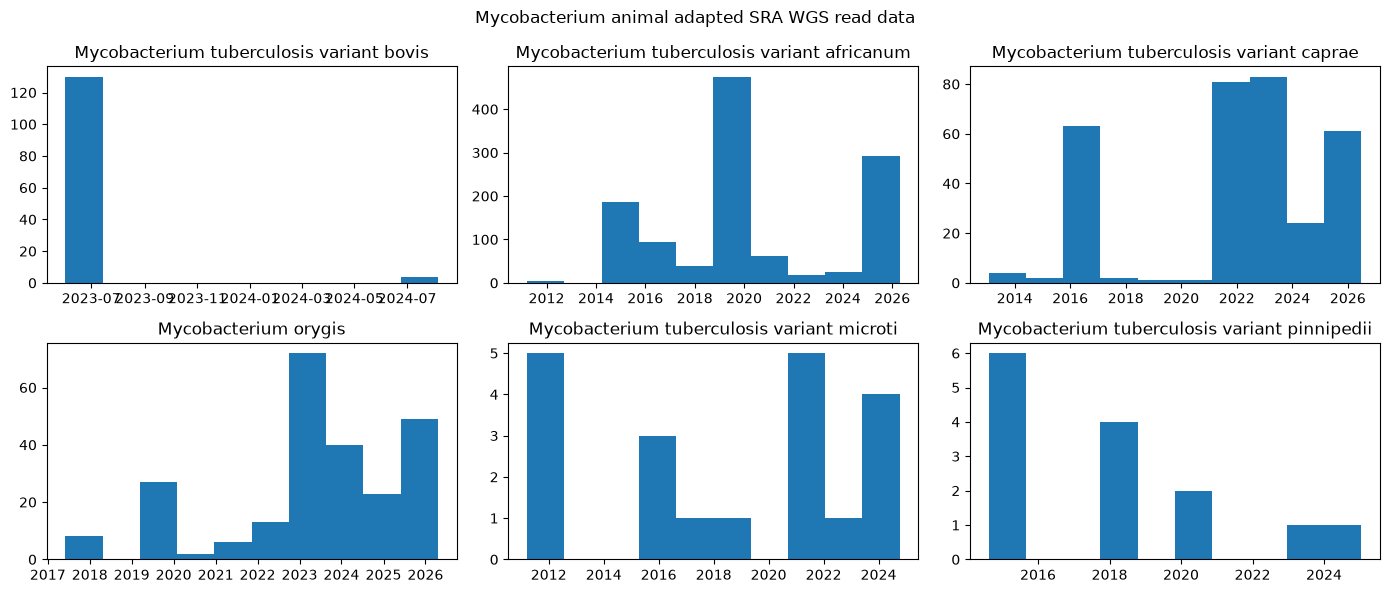

In [229]:
fig,axs=plt.subplots(2,3,figsize=(14,6))
i=0
axs=axs.flat
for s in species:
    x=sra[sra.ScientificName==s]
    dates=pd.to_datetime(x.ReleaseDate)
    dates.hist(ax=axs[i],grid=False)
    axs[i].set_title(s)
    i+=1

fig.suptitle('Mycobacterium animal adapted SRA WGS read data')
plt.tight_layout()

In [81]:
def apply_size_filter(df, min_mb=80, max_mb=500):
    """Size filter, skipped for long-read platforms."""
    
    long_read = df["Platform"].isin(["OXFORD_NANOPORE", "PACBIO_SMRT"])
    in_range = df["size_MB"].between(min_mb, max_mb)
    return df[long_read | in_range].reset_index(drop=True)

def build_project_key(df):
    """
    Creates a single grouping column that uses BioProject when available,
    falls back to CenterName when BioProject is missing/blank, and falls
    back to 'unknown' if both are missing. Treats NaN and empty/whitespace
    strings as missing.
    """
    df = df.copy()

    def clean(x):
        if pd.isna(x):
            return ""
        return str(x).strip()

    bioproject = df["BioProject"].apply(clean)
    center = df["CenterName"].apply(clean)

    df["project_key"] = np.where(
        bioproject != "", bioproject,
        np.where(center != "", center, "unknown")
    )
    return df

def stratified_sample(df, n_per_stratum=5, random_state=42):
    """
    Stratifies by ScientificName + project_key (BioProject, falling back
    to CenterName, see build_project_key). Long-read runs are always kept
    in full and don't count toward the cap.
    """
    df = build_project_key(df)

    long_read = df["Platform"].isin(["OXFORD_NANOPORE", "PACBIO_SMRT"])
    lr_df = df[long_read]
    rest_df = df[~long_read]

    sampled = (
        rest_df.groupby(["ScientificName", "project_key"], group_keys=False, dropna=False)
        .apply(lambda g: g.sample(min(len(g), n_per_stratum), random_state=random_state))
    )

    out = pd.concat([lr_df, sampled]).drop_duplicates(subset="Run")
    return out.reset_index(drop=True)
    
excluded =  ['Mycobacterium tuberculosis variant africanum GM041182','Mycobacterium tuberculosis']
filt = sra[~sra.ScientificName.isin(excluded) & (sra.year>=2019)]
strat = stratified_sample(filt, n_per_stratum=3)

len(strat)
strat.to_csv('sra_mtbc_animal_reduced.csv')

<Axes: >

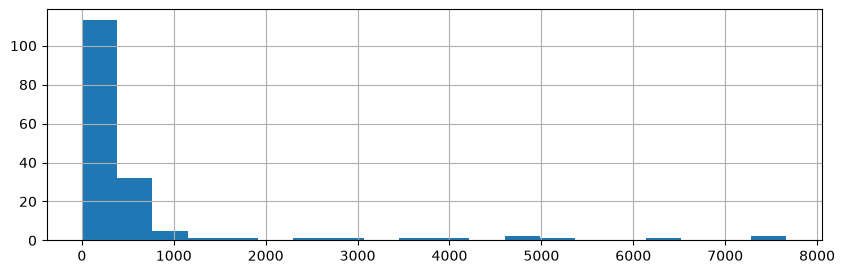

In [78]:
strat.size_MB.astype(int).hist(bins=20,figsize=(10,3))

In [79]:
cols=['Run','BioProject','ReleaseDate','CenterName','LibraryStrategy','avgLength','size_MB','source','Platform']

In [ ]:
strat.BioProject.value_counts()
strat.Platform.value_counts()
strat[cols]

In [70]:
#old reads data <2019
read_data = pd.read_csv('../genomes_data.csv')
read_data[-5:]

,ACCESSION,PAIRED,LINEAGE,ORIGIN,BIOPROJECT,BIOSAMPLE,Reads lenght (bp),LINK1,LINK2,REFERENCE
76,ERR4192405,yes,M. tuberculosis L9,Somalia,PRJEB38656,SAMEA6872244,101,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR419/005/...,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR419/005/...,"Swiss Tropical and Public Health Institute, Sw..."
77,ERR4192384,yes,M. tuberculosis L9,Europe,PRJEB38656,SAMEA6872223,101,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR419/004/...,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR419/004/...,"Swiss Tropical and Public Health Institute, Sw..."
78,ERR4162024,yes,M. tuberculosis L9,Somalia,PRJEB38317,SAMEA6847637,35-151,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR416/004/...,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR416/004/...,"Swiss Tropical and Public Health Institute, Sw..."
79,SRR3647355,yes,BCG-26,NaN,PRJNA270004,SAMN03253093,NaN,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR364/005/...,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/SRR364/005/...,pda|big_chen_group
80,ERR234151,yes,M. tuberculosis L6,NaN,PRJEB3223,SAMEA1877109,NaN,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR234/ERR2...,ftp://ftp.sra.ebi.ac.uk/vol1/fastq/ERR234/ERR2...,"Center for Public Health Research, University ..."


# new assemblies analysis

* try to extract the rd900 locus for each genome and analysis by seq alignment
* use k-mer profiling of the locus


In [ ]:
data_to_cluster = structural_matrix.dropna()    

# - metric='hamming' or 'jaccard' works best for binary presence/absence profiles
# - method='average' or 'ward' controls agglomerative clustering linkage
g = sns.clustermap(
    data_to_cluster,
    method="average",
    metric="hamming",     # Fraction of mismatched blocks between samples
    cmap="gray_r",          # Diverging colormap
    center=0.5,
    linewidths=0.5,
    figsize=(12, 10),
    col_cluster=False,     # Cluster the locus sub-blocks by co-occurrence pattern
    row_cluster=True,     # Cluster samples by structural similarity
    cbar_kws={'label': 'Presence (1) / Absence (0)'})
    

## reduce redundancy with mash

* just use this on locus itself?!

In [109]:
def run_mash(assemblies: List[str], work_dir: str, threads: int = 4):
    """Sketch all assemblies and compute the all-vs-all distance matrix. Returns path to the distances TSV."""
    
    sketch_prefix = os.path.join(work_dir, "sketches")
    subprocess.run(
        ["mash", "sketch", "-p", str(threads), "-o", sketch_prefix] + assemblies,
        check=True, capture_output=True, text=True,
    )
    sketch_file = sketch_prefix + ".msh"
 
    dist_path = os.path.join(work_dir, "distances.tsv")
    with open(dist_path, "w") as out_fh:
        subprocess.run(
            ["mash", "dist", "-p", str(threads), sketch_file, sketch_file],
            check=True, stdout=out_fh,
        )
    return dist_path
 
def cluster_by_distance(dist_path: str, threshold: float) -> Dict[str, int]:
    """Build a graph (edge if distance < threshold) and return {assembly_path: cluster_id}."""
    edges = []
    nodes = set()
    with open(dist_path) as fh:
        for line in fh:
            a, b, dist_str, *_ = line.strip().split("\t")
            nodes.update([a, b])
            if a != b and float(dist_str) < threshold:
                edges.append((a, b))
 
    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)
 
    cluster_of = {}
    for cluster_id, component in enumerate(nx.connected_components(G)):
        for node in component:
            cluster_of[node] = cluster_id
    return cluster_of
 
def pick_representatives(cluster_of: Dict[str, int]) -> pd.DataFrame:
    """For each cluster, pick the assembly with the largest total sequence length as representative."""
    rows = []
    for path, cid in cluster_of.items():
        total_len = sum(len(rec.seq) for rec in SeqIO.parse(path, "fasta"))
        rows.append({"assembly_file": path, "cluster_id": cid, "total_length": total_len})
 
    df = pd.DataFrame(rows)
    df["is_representative"] = False
    rep_idx = df.groupby("cluster_id")["total_length"].idxmax()
    df.loc[rep_idx, "is_representative"] = True
    return df.sort_values(["cluster_id", "is_representative"], ascending=[True, False])


In [201]:
files = glob.glob('mtb_genomes/*.fna')
dist_path = run_mash(files, 'temp', threads=12)
threshold=.0005
cluster_of = cluster_by_distance(dist_path,threshold)
df = pick_representatives(cluster_of)
df.to_csv("dereplication_summary.csv", index=False)

n_clusters = df["cluster_id"].nunique()
print(f"\n{len(files)} assemblies -> {n_clusters} clusters at threshold={threshold}")


684 assemblies -> 59 clusters at threshold=0.0005


In [ ]:
#write reduced assemblies to new folder
for i, r in df.iterrows():
    if r.is_representative is True:
        print (r.assembly_file)
        shutil.copy(r.assembly_file, 'mtb_reduced')

## Anchor-based extraction + MAFFT alignment paralog count

find insertions, and active-site changes

## make blast DB

In [ ]:
cmd = '''for f in mtb_reduced/*.fna; do
    acc=$(basename "$f" .fna)
    awk -v acc="$acc" '/^>/{sub(/^>/, ">" acc "|")} {print}' "$f"
done > reduced_combined.fna'''
subprocess.call(cmd, shell=True)

cmd = 'makeblastdb -in reduced_combined.fna -dbtype nucl -out reduced_db'
subprocess.call(cmd, shell=True)

In [ ]:
def make_blastdb(assembly_dir):
    assembly_path = Path(assembly_dir)
    output_file = "reduced_combined.fna"
    
    with open(output_file, "w") as outfile:
        for f in sorted(assembly_path.glob("*.fna")):
            acc = f.stem  # Gets filename without extension (equivalent to basename)
            with open(f, "r") as infile:
                for line in infile:
                    if line.startswith(">"):
                        # Replace the leading '>' with '>accession|'
                        outfile.write(f">{acc}|{line[1:]}")
                    else:
                        outfile.write(line)
                        
    # If you still need to run makeblastdb command afterwards, you can add it here:
    subprocess.run(["makeblastdb", "-in", str(output_file), "-dbtype", "nucl"], check=True)
    return output_file
    
make_blastdb('mtb_reduced')

## blast up/downstream anchors

In [141]:
cmd = '''blastn -query upstream_anchor.fa -db reduced_db \
   -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore qlen slen" \
   -max_target_seqs 1000 -max_hsps 5 > upstream_hits.tsv'''
subprocess.call(cmd, shell=True)
cmd = '''blastn -query downstream_anchor.fa -db reduced_db \
    -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore qlen slen" \
    -max_target_seqs 1000 -max_hsps 5 \
    -out downstream_hits.tsv'''
subprocess.call(cmd, shell=True)

0

In [9]:
cols = ["qseqid","sseqid","pident","length","mismatch","gapopen",
        "qstart","qend","sstart","send","evalue","bitscore","qlen","slen"]
for f in ["upstream_hits.tsv", "downstream_hits.tsv"]:
    df = pd.read_csv(f, sep="\t", names=cols)
    print(f)
    print(df[df.sseqid == "GCF_030566675.1|CP130758.1"][["sseqid","pident","length","qlen","sstart","send","bitscore"]])

upstream_hits.tsv
                         sseqid  pident  length  qlen   sstart     send  bitscore
187  GCF_030566675.1|CP130758.1  99.829    1167  1167  2949444  2950610      2145
downstream_hits.tsv
                        sseqid  pident  length  qlen   sstart     send  bitscore
65  GCF_030566675.1|CP130758.1   100.0     681   681  3685279  3685959      1258


## extract locus sequence from all genomes

In [ ]:
##correct method hopefully
COLS = ["qseqid","sseqid","pident","length","mismatch","gapopen",
        "qstart","qend","sstart","send","evalue","bitscore","qlen","slen"]
MAX_SPAN = 20_000

def load_hits(path, min_cov=0.8, min_pident=80):
    df = pd.read_csv(path, sep="\t", names=COLS)
    df["strand"] = (df["sstart"] < df["send"]).map({True: "+", False: "-"})
    df["lo"] = df[["sstart", "send"]].min(axis=1)
    df["hi"] = df[["sstart", "send"]].max(axis=1)
    df["qcov"] = df["length"] / df["qlen"]
    return df[(df["qcov"] >= min_cov) & (df["pident"] >= min_pident)]

def best_pair(u_hits, d_hits):
    """Closest pair of anchor hits on the same strand. No assumption about which anchor comes first."""
    best = None
    for _, u in u_hits.iterrows():
        for _, d in d_hits.iterrows():
            if u["strand"] != d["strand"]:
                continue
            span = int(max(u["hi"], d["hi"]) - min(u["lo"], d["lo"]) + 1)
            if best is None or span < best[0]:
                best = (span, u, d)
    return best

up = load_hits("upstream_hits.tsv")
down = load_hits("downstream_hits.tsv")
genomes = SeqIO.index("reduced_combined.fna", "fasta")

qc = []
with open("RD900_extracted.fa", "w") as out:
    for contig in sorted(set(up["sseqid"]) | set(down["sseqid"])):
        acc = contig.split("|")[0]
        u, d = up[up["sseqid"] == contig], down[down["sseqid"] == contig]
        if u.empty or d.empty:
            qc.append((acc, contig, "missing_anchor", None, None)); continue
        bp = best_pair(u, d)
        if bp is None:
            qc.append((acc, contig, "strand_mismatch", None, None)); continue
        span, uh, dh = bp
        strand = uh["strand"]
        # anchor order in the reference orientation; should be identical for every collinear genome
        if strand == "+":
            order = "up_first" if uh["lo"] < dh["lo"] else "down_first"
        else:
            order = "up_first" if uh["lo"] > dh["lo"] else "down_first"
        if span > MAX_SPAN:
            qc.append((acc, contig, "anchors_too_far", span, order)); continue

        start, end = int(min(uh["lo"], dh["lo"])), int(max(uh["hi"], dh["hi"]))
        seq = genomes[contig].seq[start - 1:end]
        if strand == "-":
            seq = seq.reverse_complement()
        out.write(f">{acc} contig={contig}:{start}-{end}({strand})\n{seq}\n")
        qc.append((acc, contig, "extracted", span, order))

qc = pd.DataFrame(qc, columns=["accession", "contig", "status", "span_bp", "ref_order"])
qc.to_csv("RD900_extraction_qc.csv", index=False)
print(qc["status"].value_counts().to_string())
print("\nanchor order among extracted genomes:")
print(qc.loc[qc["status"] == "extracted", "ref_order"].value_counts().to_string())

In [ ]:
#align the rd900 sequences
cmd = 'mafft --auto --thread 24 RD900_extracted.fa > RD900_extracted_aligned.fa'
subprocess.call(cmd, shell=True)

In [ ]:
## get quick phylogeny
cmd = 'fasttree -nt -gtr RD900_extracted_aligned.fa > RD900_locus_tree.nwk'
subprocess.call(cmd, shell=True)

## annotate locus sequences

In [ ]:
#test pathogenie
import pathogenie
featdf,recs = pathogenie.app.run_annotation('split_loci/GCF_000016925.1.fna', threads=10, kingdom='bacteria')

In [ ]:
COMBINED_FASTA = "RD900_extracted.fa"
SPLIT_DIR = "split_loci"
PROKKA_OUT = "prokka_out"
GBK_DIR = "gbk_for_clinker"
PROTEINS_DB = "RD900MAF.faa" 

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(PROKKA_OUT, exist_ok=True)
os.makedirs(GBK_DIR, exist_ok=True)

failed = []
succeeded = []
i=0
for rec in SeqIO.parse(COMBINED_FASTA, "fasta"):
    if i>5:
        break
    i+=1   
    # rec.id is whatever comes before the first space in the FASTA header --
    # in your extraction output that's the accession (e.g. "GCF_030566675.1")
    accession = rec.id
    split_path = os.path.join(SPLIT_DIR, f"{accession}.fna")
    SeqIO.write(rec, split_path, "fasta")

    out_dir = os.path.join(PROKKA_OUT, accession)
    locustag = accession.replace(".", "_").replace("-", "_")
    env_bin = os.path.expanduser("/local/miniconda3/envs/prokka_env/bin")
    env = {**os.environ, "PATH": env_bin + ":" + os.environ["PATH"]}    
    cmd = [
        f"{env_bin}/prokka", "--outdir", out_dir, "--prefix", accession,
        "--proteins", PROTEINS_DB,
        "--kingdom", "Bacteria", "--gcode", "11",
        "--locustag", locustag,
        "--force", "--quiet", split_path,
    ]
    print(f"Annotating {accession} ...")
    print (cmd)
    result = subprocess.run(cmd, capture_output=True, text=True)

    if result.returncode != 0:
        print(f"  [FAILED] {accession}: {result.stderr.strip()[-800:]}")
        failed.append(accession)
        continue

    gbk_src = os.path.join(out_dir, f"{accession}.gbk")
    gbk_dst = os.path.join(GBK_DIR, f"{accession}.gbk")
    shutil.copy(gbk_src, gbk_dst)
    succeeded.append(accession)
    
print(f"\n{len(succeeded)} annotated OK, {len(failed)} failed: {failed}")
print(f"GBK files ready for clinker in: {GBK_DIR}/")

In [ ]:
def load_queries(path):
    """Return [(gene, product, protein)]. Handles '>id name~~~product~~~x' headers."""
    queries = []
    for rec in SeqIO.parse(path, "fasta"):
        desc = rec.description[len(rec.id):].strip()
        parts = [p.strip() for p in desc.split("~~~") if p.strip()]
        product = max(parts, key=len) if parts else "hypothetical protein"
        queries.append((rec.id, product, str(rec.seq).upper().rstrip("*")))
    return queries

def orf_segments(dna, min_orf):
    """Yield (strand, strand_seq, frame, aa_offset, protein_segment, has_stop)
    for every stop-delimited segment in the 6 frames."""
    rc = str(Seq(dna).reverse_complement())
    for strand, s in ((1, dna), (-1, rc)):
        for frame in range(3):
            n = (len(s) - frame) // 3
            prot = str(Seq(s[frame:frame + 3 * n]).translate(table=11))
            offset = 0
            for seg in prot.split("*"):
                has_stop = offset + len(seg) < len(prot)
                if len(seg) >= min_orf:
                    yield strand, s, frame, offset, seg, has_stop
                offset += len(seg) + 1

def find_hits(dna, queries, index, aligner, args):
    L = len(dna)
    hits = []
    for strand, s, frame, offset, seg, has_stop in orf_segments(dna, args.min_orf):
        counts = Counter()
        for i in range(len(seg) - K + 1):
            for qi in index.get(seg[i:i + K], ()):
                counts[qi] += 1
        for qi, c in counts.items():
            if c < args.min_kmers:
                continue
            gene, product, q = queries[qi]
            aln = aligner.align(q, seg)[0]
            qblocks, tblocks = aln.aligned
            aligned = sum(e - b for b, e in qblocks)
            matches = sum(a == b
                          for (qs, qe), (ts, te) in zip(qblocks, tblocks)
                          for a, b in zip(q[qs:qe], seg[ts:te]))
            ident, cov = matches / aligned, aligned / len(q)
            if ident < args.min_id or cov < args.min_cov:
                continue

            # Start: where the query's residue 1 should sit, snapped to a start codon
            q0, t0 = int(qblocks[0][0]), int(tblocks[0][0])
            expected = t0 - q0

            def codon(p):
                a = frame + 3 * (offset + p)
                return s[a:a + 3]

            starts = [p for p in range(max(0, expected - 10), t0 + 1) if codon(p) in STARTS]
            p = min(starts, key=lambda x: (abs(x - expected), x)) if starts else t0

            protein = seg[p:]
            if codon(p) in STARTS:
                protein = "M" + protein[1:]

            start_nt = frame + 3 * (offset + p)
            end_nt = frame + 3 * (offset + len(seg)) + (3 if has_stop else 0)
            if strand == 1:
                fs, fe = start_nt, end_nt
            else:
                fs, fe = L - end_nt, L - start_nt

            hits.append(dict(start=int(fs), end=int(fe), strand=strand, score=aln.score,
                             gene=gene, product=product, protein=protein,
                             ident=ident, cov=cov))

    # Keep best-scoring hit when two overlap by more than half of the shorter one
    kept = []
    for h in sorted(hits, key=lambda h: -h["score"]):
        clash = False
        for k in kept:
            ov = min(h["end"], k["end"]) - max(h["start"], k["start"])
            if ov > 0.5 * min(h["end"] - h["start"], k["end"] - k["start"]):
                clash = True
                break
        if not clash:
            kept.append(h)
    return sorted(kept, key=lambda h: h["start"])

def write_gbk(rec_id, description, dna, hits, outdir, stem):
    tag = re.sub(r"\W", "_", rec_id)[:12]
    out = SeqRecord(
        Seq(dna), id=rec_id, name=re.sub(r"\W", "_", rec_id)[:16], description=description,
        annotations={"molecule_type": "DNA", "topology": "linear"},
    )
    for n, h in enumerate(hits, 1):
        out.features.append(SeqFeature(
            FeatureLocation(h["start"], h["end"], strand=h["strand"]),
            type="CDS",
            qualifiers={
                "locus_tag": [f"{tag}_{n:03d}"],
                "gene": [h["gene"]],
                "product": [h["product"]],
                "transl_table": ["11"],
                "translation": [h["protein"]],
                "note": [f"best match {h['gene']}: {h['ident']:.0%} identity, "
                         f"{h['cov']:.0%} query coverage"],
            },
        ))
    path = Path(outdir) / f"{stem}.gbk"
    SeqIO.write(out, path, "genbank")
    return path

def expand_inputs(inputs):
    """Turn files / folders into a list of FASTA paths."""
    files = []
    for item in inputs:
        p = Path(item)
        if p.is_dir():
            for pat in ("*.fna", "*.fa", "*.fasta", "*.fna.gz", "*.fa.gz", "*.fasta.gz"):
                files.extend(sorted(p.glob(pat)))
        else:
            files.append(p)
    return files


def read_fasta(path):
    opener = gzip.open if path.suffix == ".gz" else open
    with opener(path, "rt") as fh:
        yield from SeqIO.parse(fh, "fasta")




## extract -> reduce -> cluster locii workflow

In [206]:
def gene_order_signature(gbk_path, normalize=True):
    """
    Ordered tuple of (gene_name, strand) for a locus's CDS features, sorted
    by position -- the structural fingerprint used for grouping.

    normalize=True strips Prokka/Bakta-style auto-disambiguation suffixes
    (e.g. "pknH2_1" -> "pknH2") so two loci with identical gene content
    don't split into different groups just because one annotation run
    happened to append a suffix and the other didn't.
    """
    rec = SeqIO.read(gbk_path, "genbank")
    cds = sorted((f for f in rec.features if f.type == "CDS"), key=lambda f: int(f.location.start))
    sig = []
    for f in cds:
        name = f.qualifiers.get("gene", [f.qualifiers.get("locus_tag", ["?"])[0]])[0]
        if normalize:
            name = re.sub(r"_\d+$", "", name)
        strand = "+" if f.location.strand == 1 else "-"
        sig.append((name, strand))
    return tuple(sig)

def group_loci_by_structure(gbk_paths, normalize=True):
    """Group loci into structural classes sharing an identical gene-order signature."""
    groups = defaultdict(list)
    for path in gbk_paths:
        acc = os.path.splitext(os.path.basename(path))[0]
        sig = gene_order_signature(path, normalize=normalize)
        groups[sig].append(acc)
    return dict(groups)

def describe_structure(sig):
    return " - ".join(f"{name}({strand})" for name, strand in sig) or "(no CDS)"


def _run_mash(fasta_paths, work_dir):
    os.makedirs(work_dir, exist_ok=True)
    sketch_prefix = os.path.join(work_dir, "sketches")
    subprocess.run(["mash", "sketch", "-o", sketch_prefix] + fasta_paths, check=True, capture_output=True, text=True)
    dist_path = os.path.join(work_dir, "distances.tsv")
    with open(dist_path, "w") as out:
        subprocess.run(["mash", "dist", sketch_prefix + ".msh", sketch_prefix + ".msh"], check=True, stdout=out)
    return dist_path


def _cluster_by_distance(dist_path, threshold):
    G = nx.Graph()
    with open(dist_path) as fh:
        for line in fh:
            a, b, dist_str, *_ = line.strip().split("\t")
            G.add_nodes_from([a, b])
            if a != b and float(dist_str) < threshold:
                G.add_edge(a, b)
    return {node: cid for cid, comp in enumerate(nx.connected_components(G)) for node in comp}

def select_representatives(
    gbk_dir, loci_fasta_dir, out_dir="structure_results",
    mash_threshold=0.01, normalize_gene_names=True,
):
    """
    Group extracted loci by structural signature (gene content + order from
    annotation), then within each structural group collapse near-identical
    sequences via Mash and keep one representative per sub-cluster -- so the
    final set covers every distinct locus STRUCTURE, and within a structure,
    every meaningfully distinct SEQUENCE variant.
    """
    os.makedirs(out_dir, exist_ok=True)
    gbk_paths = sorted(glob.glob(os.path.join(gbk_dir, "*.gbk")))
    structure_groups = group_loci_by_structure(gbk_paths, normalize=normalize_gene_names)

    rows, representatives = [], []
    for struct_id, (sig, members) in enumerate(sorted(structure_groups.items(), key=lambda kv: -len(kv[1]))):
        struct_label = describe_structure(sig)
        fasta_paths = [os.path.join(loci_fasta_dir, f"{acc}.fna") for acc in members]

        if len(members) == 1:
            sub_cluster_of = {members[0]: 0}
        else:
            dist_path = _run_mash(fasta_paths, os.path.join(out_dir, f"_mash_struct{struct_id}"))
            raw = _cluster_by_distance(dist_path, mash_threshold)
            sub_cluster_of = {os.path.splitext(os.path.basename(p))[0]: raw[p] for p in fasta_paths}

        by_subcluster = defaultdict(list)
        for acc in members:
            by_subcluster[sub_cluster_of[acc]].append(acc)

        for sc, accs in by_subcluster.items():
            lengths = {a: len(SeqIO.read(os.path.join(loci_fasta_dir, f"{a}.fna"), "fasta").seq) for a in accs}
            rep = max(lengths, key=lengths.get)
            representatives.append(rep)
            for a in accs:
                rows.append({"accession": a, "structure_id": struct_id, "structure": struct_label,
                             "n_genes": len(sig), "mash_subcluster": sc, "is_representative": (a == rep)})

    summary = pd.DataFrame(rows)
    summary.to_csv(os.path.join(out_dir, "structure_summary.csv"), index=False)
    print(f"{len(summary)} loci -> {summary['structure_id'].nunique()} structural types -> {len(representatives)} representatives")
    print(summary.groupby(["structure_id", "structure"]).agg(
        n_members=("accession", "size"), n_subclusters=("mash_subcluster", "nunique")).to_string())
    return summary, representatives

In [215]:
def split_fasta(infile, splitdir):
    os.makedirs(splitdir, exist_ok=True)
    for rec in SeqIO.parse(infile, "fasta"):
        # rec.id is whatever comes before the first space in the FASTA header --
        # in your extraction output that's the accession (e.g. "GCF_030566675.1")
        accession = rec.id
        split_path = os.path.join(splitdir, f"{accession}.fna")
        SeqIO.write(rec, split_path, "fasta")

split_fasta('RD900_extracted_lr.fa', 'split_loci')

In [216]:
summary, representatives = select_representatives(
    gbk_dir="annot_test",     # your Bakta output
    loci_fasta_dir="split_loci",    # your per-genome extracted locus fastas
    mash_threshold=0.01,
)


103 loci -> 4 structural types -> 4 representatives
                                                               n_members  n_subclusters
structure_id structure                                                                 
0            MAF(+) - pknH1(-) - tbd2(-) - pknH2(-) - embR(-)         53              1
1            MAF(+) - pknH1(-) - embR(-)                              47              1
2            MAF(+) - pknH1(-) - tbd2(-) - embR(-)                     2              1
3            pknH2(-)                                                  1              1


## visualise locus comparison

In [172]:
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from matplotlib import cm
from Bio import SeqIO
from dna_features_viewer import BiopythonTranslator

import os
import itertools
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
from Bio import SeqIO
from dna_features_viewer import BiopythonTranslator

def plot_locus_comparison(
    gbk_paths,
    metadata_df=None,
    accession_col=None,
    label_col=None,
    gene_colors=None,
    link_adjacent_only=True,
    show_gene_labels=True,     # False draws plain colored arrows + a shared legend instead
    row_height=0.5,             # compact default; vertical space per row in inches
    hspace=0.15,                 # gap between rows, in subplot-fraction units
    left_margin=None,           # figure-fraction left margin for row labels; auto-estimated if None
    link_alpha=0.4,
    link_linewidth=2,
):
    """
    Plot several annotated loci (GenBank files) stacked vertically, genes colored
    consistently by name across all rows, with connecting lines between matching
    genes in adjacent rows (clinker-style).
    Returns (fig, axes).
    """
    records = [SeqIO.read(p, "genbank") for p in gbk_paths]
    accessions = [os.path.splitext(os.path.basename(p))[0] for p in gbk_paths]

    if metadata_df is not None and accession_col and label_col:
        lookup = metadata_df.set_index(accession_col)[label_col].to_dict()
        labels = []
        for acc in accessions:
            if acc in lookup:
                labels.append(str(lookup[acc]))
            else:
                print(f"[warn] no metadata match for '{acc}' in column '{accession_col}'; using accession as label")
                labels.append(acc)
    else:
        labels = accessions

    if gene_colors is None:
        all_genes = sorted({
            f.qualifiers.get("gene", [""])[0]
            for rec in records for f in rec.features
            if f.qualifiers.get("gene", [""])[0]
        })
        palette = mpl.colormaps["tab20"].colors   # current mpl API (cm.get_cmap is deprecated)
        gene_colors = {g: palette[i % len(palette)] for i, g in enumerate(all_genes)}

    class ColorByGeneName(BiopythonTranslator):
        def compute_feature_color(self, feature):
            return gene_colors.get(feature.qualifiers.get("gene", [""])[0], "#CCCCCC")
        def compute_feature_label(self, feature):
            if not show_gene_labels:
                return None
            return feature.qualifiers.get("gene", [""])[0]

    translator = ColorByGeneName()

    if left_margin is None:
        max_label_len = max((len(l) for l in labels), default=0)
        left_margin = min(0.05 + 0.011 * max_label_len, 0.4)

    fig, axes = plt.subplots(len(records), 1, figsize=(9, row_height * len(records)))
    if len(records) == 1:
        axes = [axes]

    gene_positions = []
    max_len = max(len(rec.seq) for rec in records)
    for ax, rec, label in zip(axes, records, labels):
        gr = translator.translate_record(rec)
        _, (levels, _) = gr.plot(ax=ax, with_ruler=False)
        max_level = max(levels.values(), default=0)
        # crop the large vertical headroom DFV reserves by default for external
        # label placement -- this is what was making short rows look "truncated"
        ax.set_ylim(-0.7, max_level + 1.3)
        ax.set_xlim(0, max_len)
        # ax.text(), not ax.set_ylabel(rotation=0, ...): with a non-default axes
        # left position (which subplots_adjust gives us), set_ylabel(rotation=0)
        # silently anchors the label off the left edge of the FIGURE rather than
        # the axes -- it was being drawn, just entirely off-canvas.
        ax.text(-0.02, 0.5, label, transform=ax.transAxes,
                ha="right", va="center", fontsize=12)
        positions = {
            f.qualifiers.get("gene", [""])[0]: (int(f.location.start), int(f.location.end))
            for f in rec.features if f.qualifiers.get("gene", [""])[0]
        }
        gene_positions.append(positions)

    for ax in axes[:-1]:
        ax.tick_params(labelbottom=False)

    '''row_pairs = (
        zip(range(len(axes) - 1), range(1, len(axes)))
        if link_adjacent_only
        else itertools.combinations(range(len(axes)), 2)
    )
    for i, j in row_pairs:
        shared = set(gene_positions[i]) & set(gene_positions[j])
        for gene in shared:
            s_i, e_i = gene_positions[i][gene]
            s_j, e_j = gene_positions[j][gene]
            con = ConnectionPatch(
                xyA=((s_i + e_i) / 2, 0), coordsA=axes[i].transData,
                xyB=((s_j + e_j) / 2, 1), coordsB=axes[j].transData,
                color=gene_colors.get(gene, "#999999"),
                alpha=link_alpha, linewidth=link_linewidth,
            )
            fig.add_artist(con)'''

    # not using plt.tight_layout() -- it was failing to accommodate the row
    # labels and silently cropping them out of the saved/displayed figure.
    fig.subplots_adjust(left=left_margin, right=0.98, top=0.98, bottom=0.05, hspace=hspace)

    if not show_gene_labels:
        handles = [mpatches.Patch(color=c, label=g) for g, c in gene_colors.items()]
        fig.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5),
                   fontsize=12, frameon=False, title="Gene")

    return fig, axes

[warn] no metadata match for 'SRR8952882' in column 'AssemblyAccession'; using accession as label


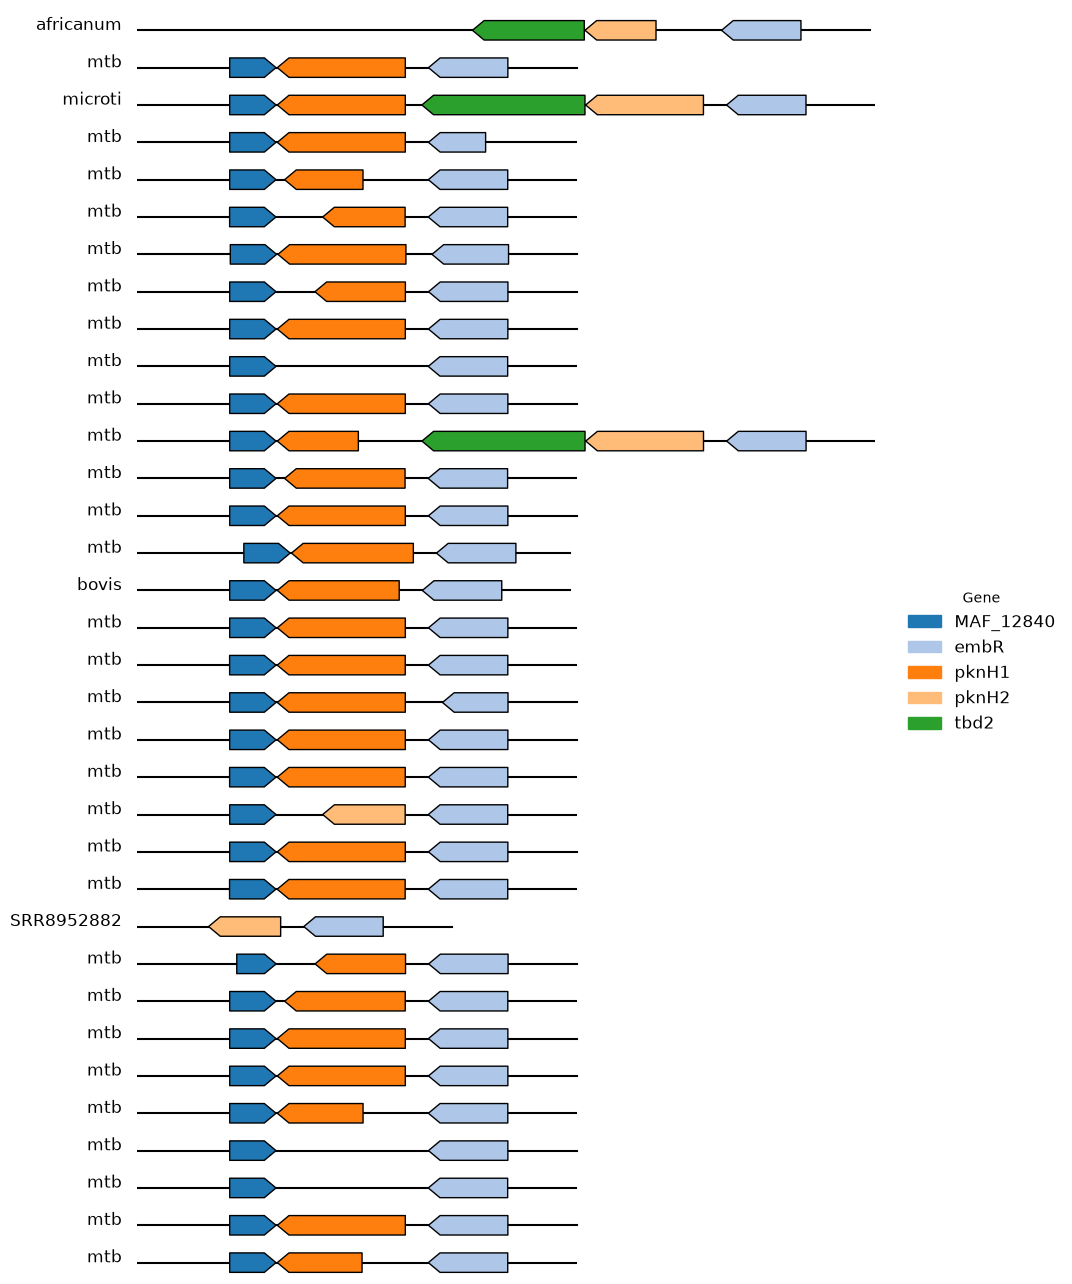

In [173]:
gbk_paths_ordered = glob.glob('annot/*.gbk') 

fig, axes = plot_locus_comparison(
    gbk_paths=gbk_paths_ordered,
    metadata_df=mtb_asm,
    accession_col="AssemblyAccession",
    label_col="species",
    row_height=0.4,          # tune for minimal vertical space
    show_gene_labels=False,  # legend instead
)

## weird Brazil sample check